In [1]:
"""
auteur:Alexandre
date:2024/09/03
"""

# Reproduction du modèle utilisé pour les élections présidentielles

'\nauteur:Alexandre\ndate:2024/09/03\n'

# **Modèle de Transfert de Voix**

## Chargement des données

In [2]:
import pandas as pd
import params as prm
import numpy as np

In [3]:
df_1f = pd.read_csv(prm.datasets_pp_path / f"DF_{prm.dataset_1er_tour}.csv")
df_2f = pd.read_csv(prm.datasets_pp_path / f"DF_{prm.dataset_2nd_tour}.csv")
print(df_1f.shape, df_2f.shape)

(61593, 23) (61593, 18)


## Définition du modèle

In [4]:
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import torch

In [5]:
class TransfertVoix(torch.nn.Module):
    def __init__(self, N_1er, N_2eme):
        super(TransfertVoix, self).__init__()
        
        self.lin = torch.nn.Linear(N_2eme, N_1er, bias=False)

    def forward(self, p_1):
    
        M = torch.softmax(self.lin.weight, axis=1)
        p_2_pred = torch.matmul(p_1, M)
        
        return p_2_pred

In [6]:
# def pdf_loss(p_pred, p, weight):

    # ind_nonzero = (p==0) + (p_pred==0)
    # p[ind_nonzero] = 1.
    # p_pred[ind_nonzero] = 1.
    # kl_div = p * (p.log() - p_pred.log())
    # loss_train = (kl_div * weight[:, None]).sum()
    
    # return loss_train


def pdf_loss(p_pred, p, weight):

    mask = (p == 0) | (p_pred == 0)

    p = torch.where(mask, torch.ones_like(p), p)
    p_pred = torch.where(mask, torch.ones_like(p_pred), p_pred)

    kl_div = p * (p.log() - p_pred.log())
    loss_train = (kl_div * weight[:, None]).sum()

    return loss_train

In [7]:
def fit_data(
    df_1f,
    df_2f,
    
    lr=1e-5,
    batch_size=2**5,
    num_epochs=500,
    
    seed=2024,
    device=None
):

    # Preparation des données
    pre_X_train, pre_X_test, pre_Y_train, pre_Y_test = train_test_split(
        df_1f, df_2f, 
        test_size=.2, 
        random_state=seed, 
        shuffle=True
    )
    X_train, X_test = pre_X_train[pre_X_train.keys()[:-1]], pre_X_test[pre_X_test.keys()[:-1]]
    Y_train, Y_test = pre_Y_train[pre_Y_train.keys()[:-1]], pre_Y_test[pre_Y_test.keys()[:-1]]

    loader = DataLoader(
        TensorDataset(
            torch.Tensor(X_train.to_numpy()), 
            torch.Tensor(Y_train.to_numpy())
        ), batch_size=batch_size, shuffle=True
    )
    
    # Préparation du modèle
    N_1er, N_2eme = X_train.shape[-1], Y_train.shape[-1]
    trans = TransfertVoix(N_1er, N_2eme).to(device)

    # Préparation de l'apprentissage
    optimizer = torch.optim.Adam(
        trans.parameters(), 
        lr=lr,
        foreach=False,
        fused=False
    )

    losses_train = []
    losses_test = []

    for epoch in tqdm(range(int(num_epochs)), desc=f"Computing on {device}"):
        
        for p_1, p_2 in loader:

            p_1 = p_1.to(device)
            p_2 = p_2.to(device)

            sum_1 = p_1.sum(dim=1, keepdim=True)
            sum_2 = p_2.sum(dim=1, keepdim=True)

            p_1t = p_1 / sum_1
            p_2t = p_2 / sum_2

            p_2_pred = trans(p_1t)
            
            weight = sum_2 / sum_2.sum()

            loss_train = pdf_loss(p_2_pred, p_2t, weight)

            optimizer.zero_grad()
            loss_train.backward()
            optimizer.step()
            
        losses_train.append(loss_train.item())

        with torch.no_grad():
            
            x_test = torch.Tensor(X_test.to_numpy()).to(device)
            sum_test_1 = x_test.sum(dim=-1, keepdim=True).to(device)
            sum_test_1[np.where(sum_test_1.cpu() == 0)] = 1

            y_test = torch.Tensor(Y_test.to_numpy()).to(device)
            sum_test_2 = y_test.sum(dim=-1, keepdim=True).to(device)
            sum_test_2[np.where(sum_test_2.cpu() == 0)] = 1

            Y_pred = trans(x_test / sum_test_1)
            
            weight = sum_test_2 / sum_test_2.sum()

            losse_test = pdf_loss(Y_pred, y_test / sum_test_2, weight)
            losses_test.append(losse_test.item())

    return trans, np.array(losses_train), np.array(losses_test), Y_pred.cpu().detach().numpy(), (y_test / sum_test_2).cpu().detach().numpy()

## Entrainement du modèle

In [8]:
batch_size = 2**10
num_epochs = 200
lr = 1e-3

In [9]:
trans, losses_train, losses_test, pred, test = fit_data(
    df_1f=df_1f,
    df_2f=df_2f,
    batch_size=batch_size,
    num_epochs=num_epochs,
    device=prm.device,
    lr=lr
)

Computing on xpu: 100%|██████████| 200/200 [03:30<00:00,  1.05s/it]


In [10]:
# Path pour l'enregistrement des données
results_path = prm.results_path / f"Ca_model_original"
results_path.mkdir(exist_ok=True)

np.save(results_path / "loss_train", losses_train)
np.save(results_path / "loss_test", losses_test)
np.save(results_path / "pred", pred)
np.save(results_path / "test", test)
np.save(results_path / "matrice", torch.softmax(trans.lin.weight, axis=1).cpu().detach().numpy())

# Enregistrement des paramètres de l'entrainement
fichier = open(results_path / "info.txt", "w")
fichier.write(f"{num_epochs = }\n")
fichier.write(f"{batch_size = }\n")
fichier.write(f"{lr = }")
fichier.close()

## Représentation des résultats

In [11]:
import matplotlib.pyplot as plt

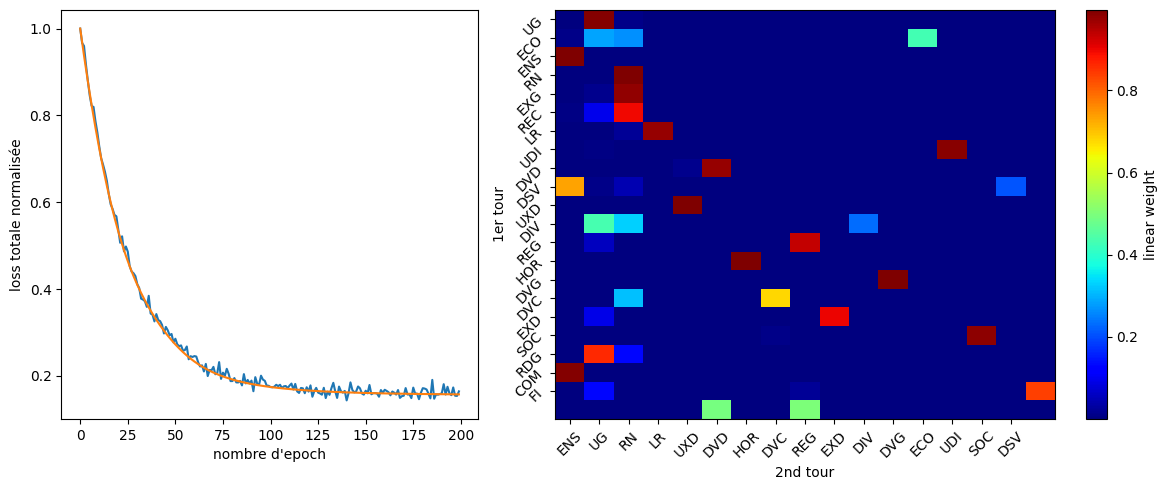

In [12]:
fig,ax = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12,5),
    gridspec_kw={"width_ratios":[0.4,0.6]},
    dpi=100
)

ax[0].plot(
    range(num_epochs),
    losses_train / losses_train.max()
)
ax[0].plot(
    range(num_epochs),
    losses_test / losses_test.max()
)
ax[0].set_xlabel("nombre d'epoch")
ax[0].set_ylabel("loss totale normalisée")

m1 = ax[1].imshow(
    # trans.lin.weight.cpu().detach().numpy(),
    torch.softmax(trans.lin.weight, axis=1).cpu().detach().numpy(),
    cmap="jet", aspect="auto",
    # vmin=-6, vmax=+6
)
cbar = fig.colorbar(m1, ax=ax[1])
cbar.set_label("linear weight")
ax[1].set_xticks(
    range(df_2f.keys()[:-2].shape[-1]),
    df_2f.keys()[:-2],
    rotation=45
)
ax[1].set_yticks(
    range(df_1f.keys()[:-2].shape[-1]),
    df_1f.keys()[:-2],
    rotation=45
)
ax[1].set_xlabel("2nd tour")
ax[1].set_ylabel("1er tour")

plt.tight_layout()
plt.show()

In [13]:
report = torch.softmax(trans.lin.weight, axis=1).cpu().detach().numpy() * 100
cmap = prm.cm.tab20

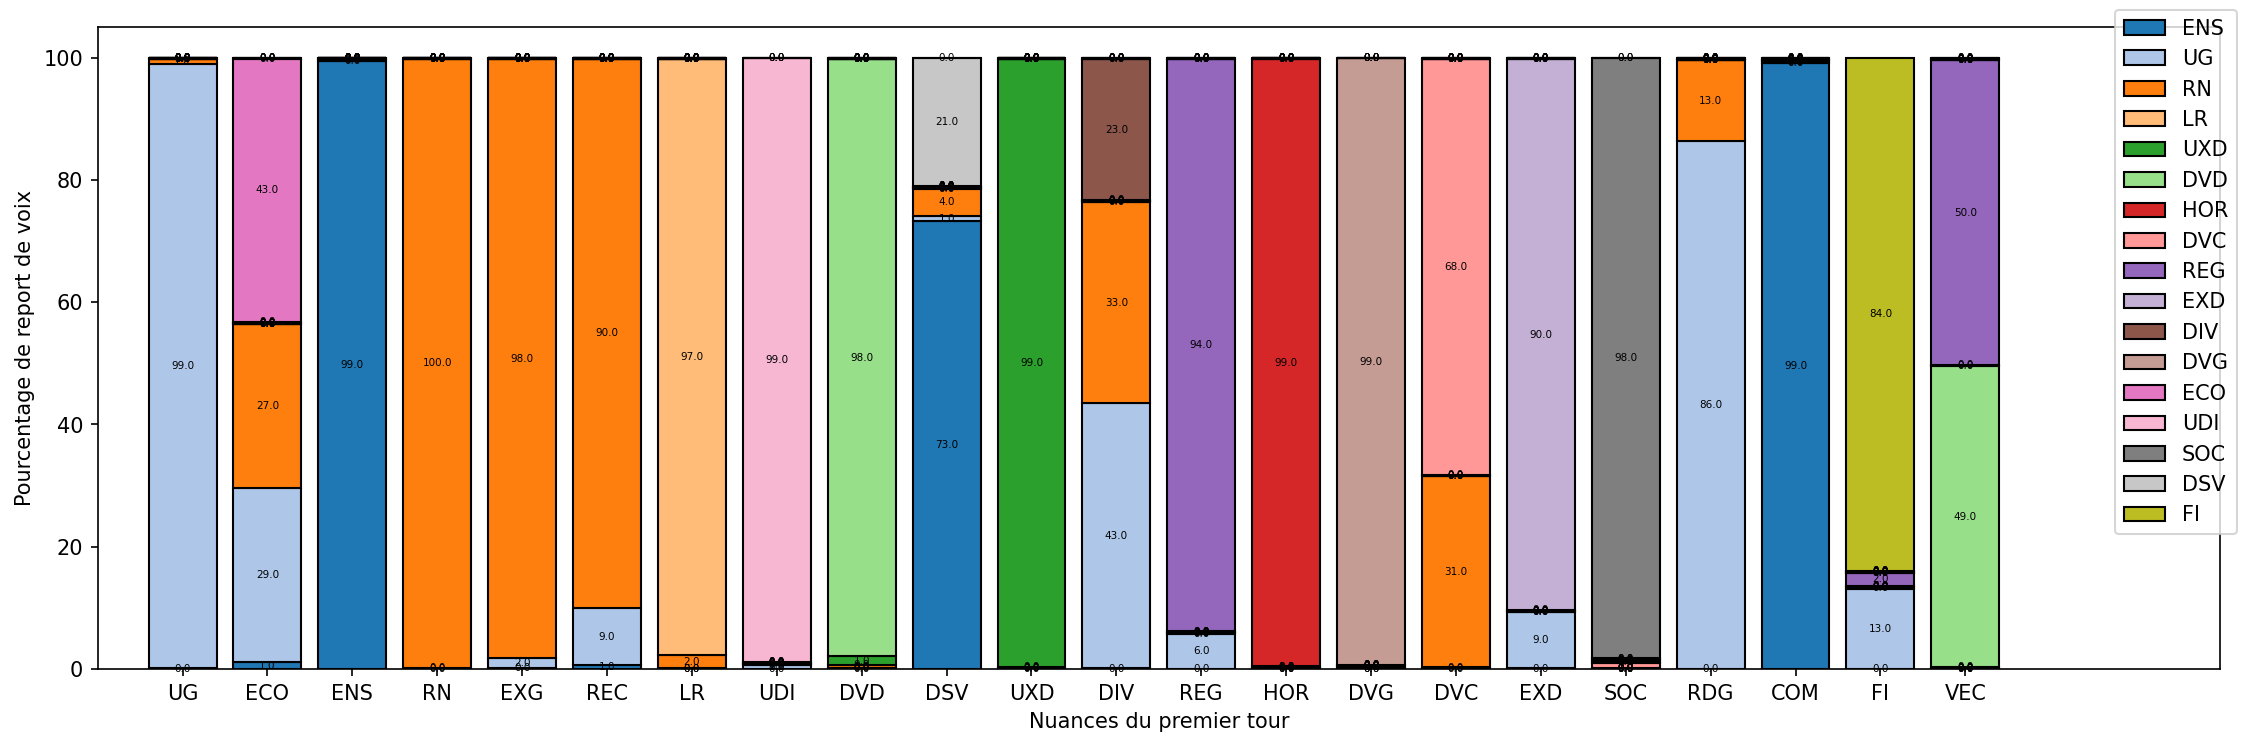

In [14]:
fig,ax = plt.subplots(
    ncols=1,
    nrows=1,
    figsize=(15,5),
    dpi=150
)

for i in range(df_2f.shape[-1]-1):
    
    b = ax.bar(
        df_1f.keys()[:-1],
        height=report[:,i],
        bottom=report[:,:i].sum(axis=1),
        label=df_2f.keys()[i],
        color=cmap(i),
        edgecolor="black",
        linewidth=1
    )
    ax.bar_label(
        b,
        np.round(report[:,i]),
        label_type="center",
        size=5
    )

ax.set_xlabel("Nuances du premier tour")
ax.set_ylabel("Pourcentage de report de voix")
ax.set_xlim(-1, 24)
fig.legend()

plt.tight_layout()
plt.show()

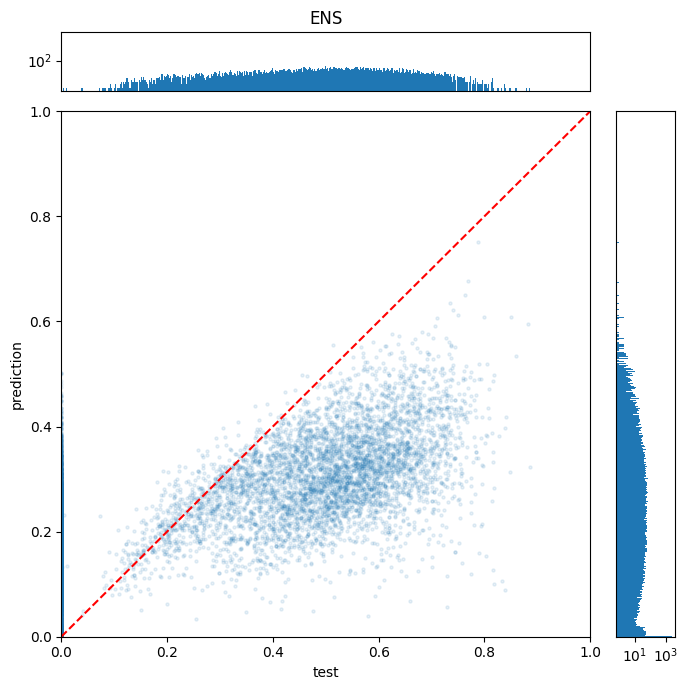

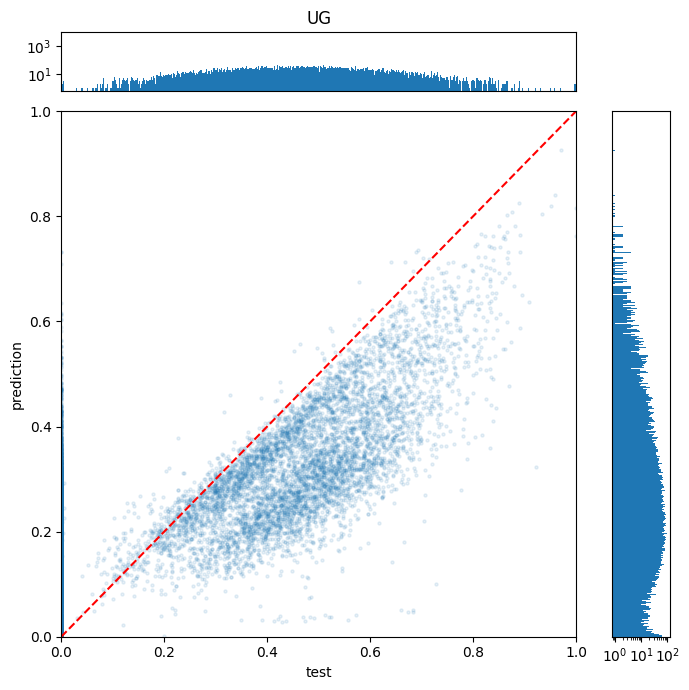

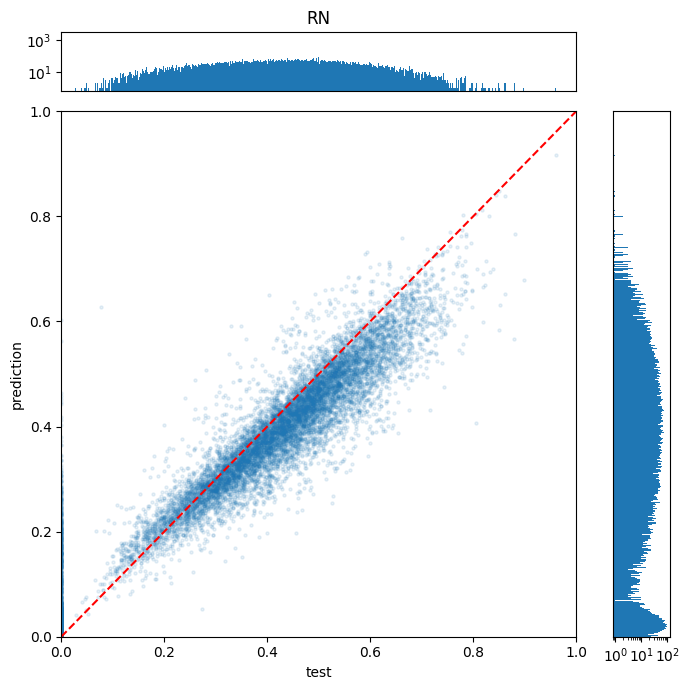

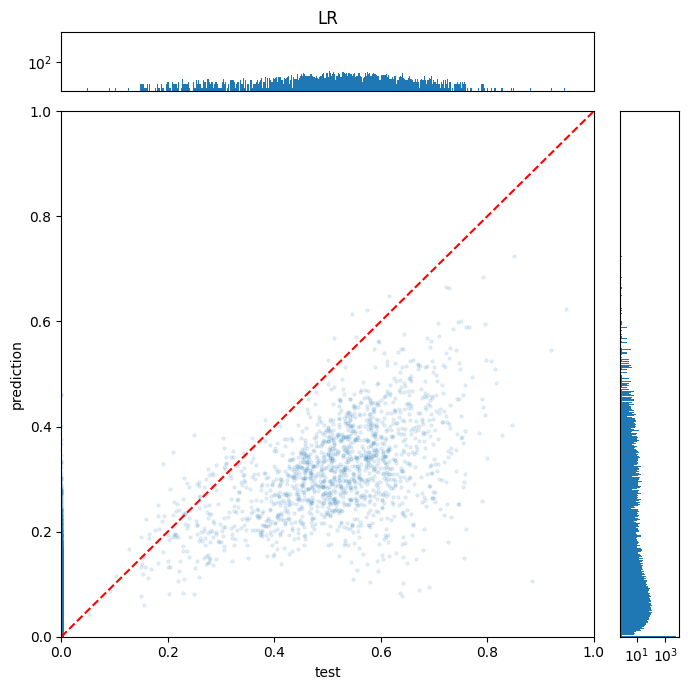

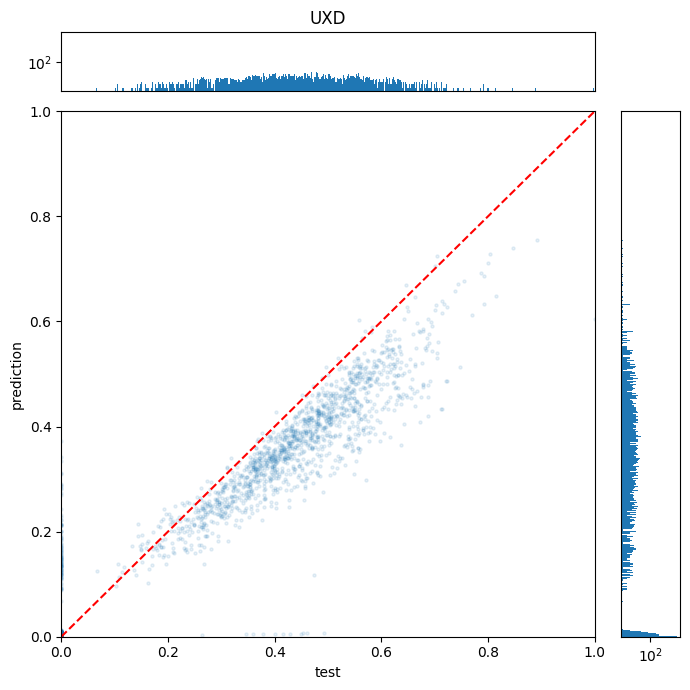

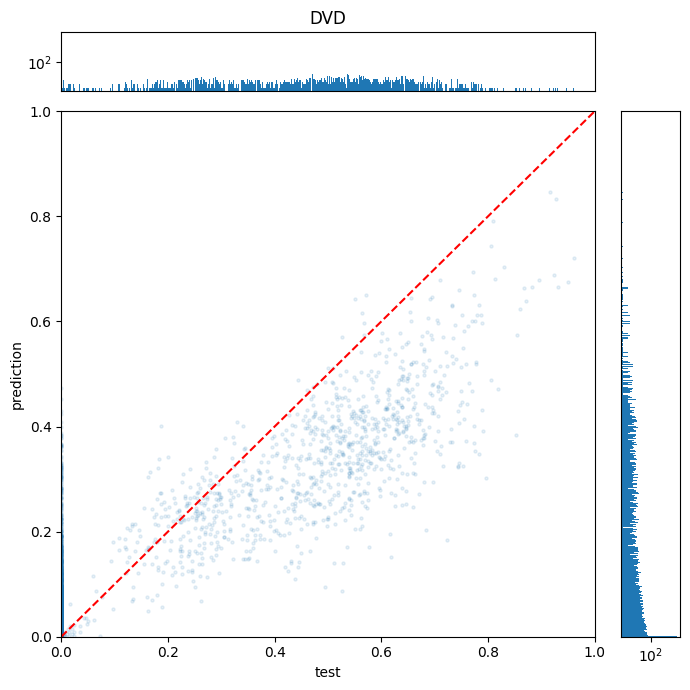

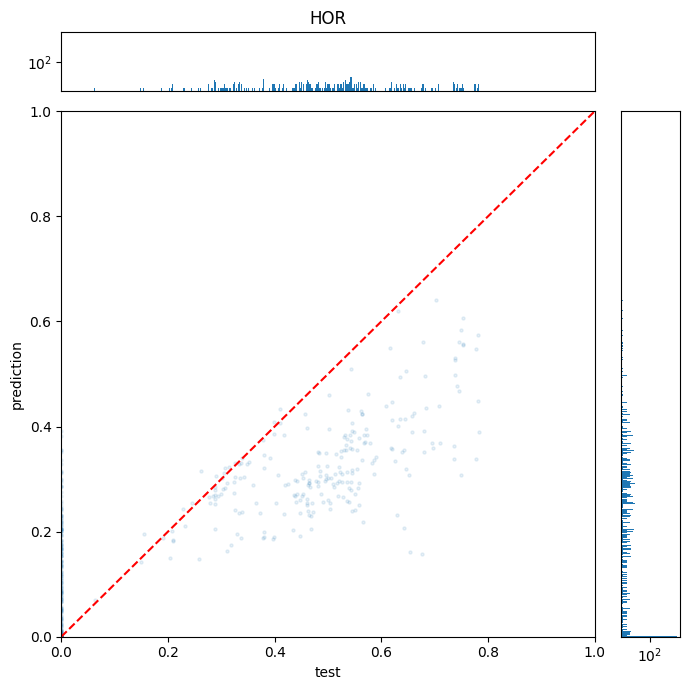

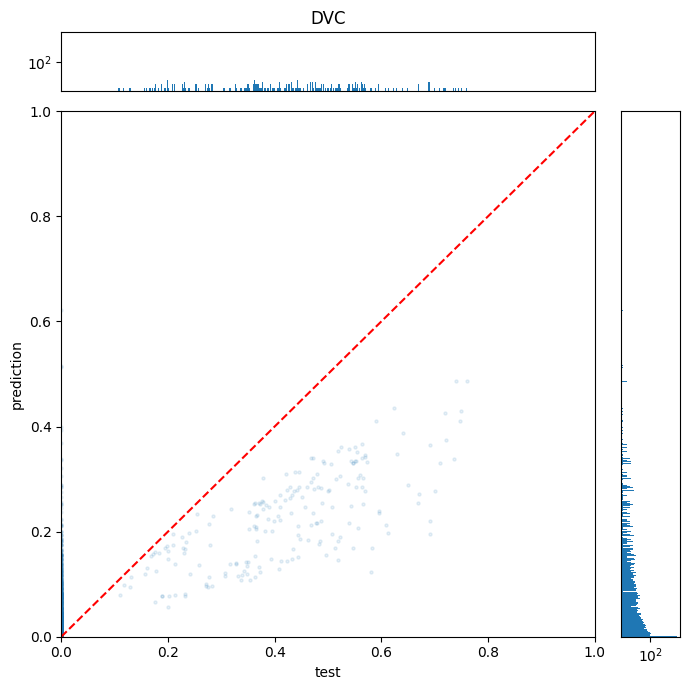

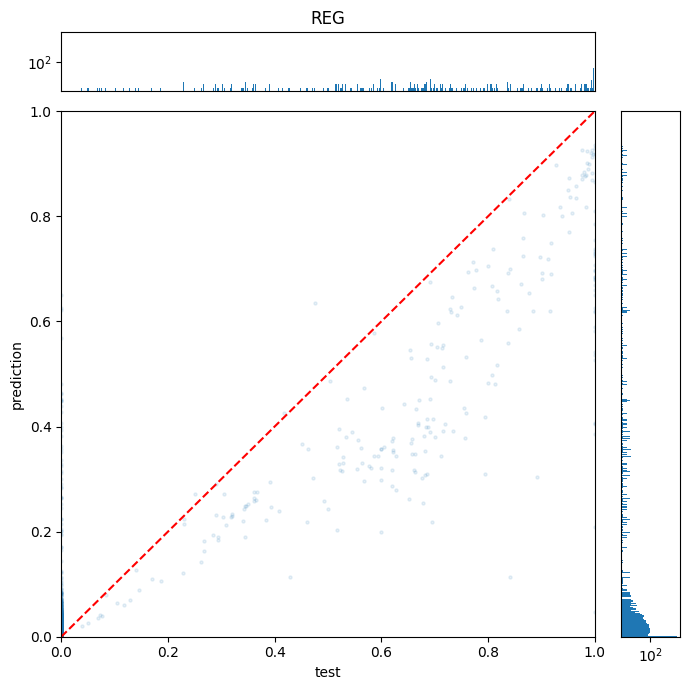

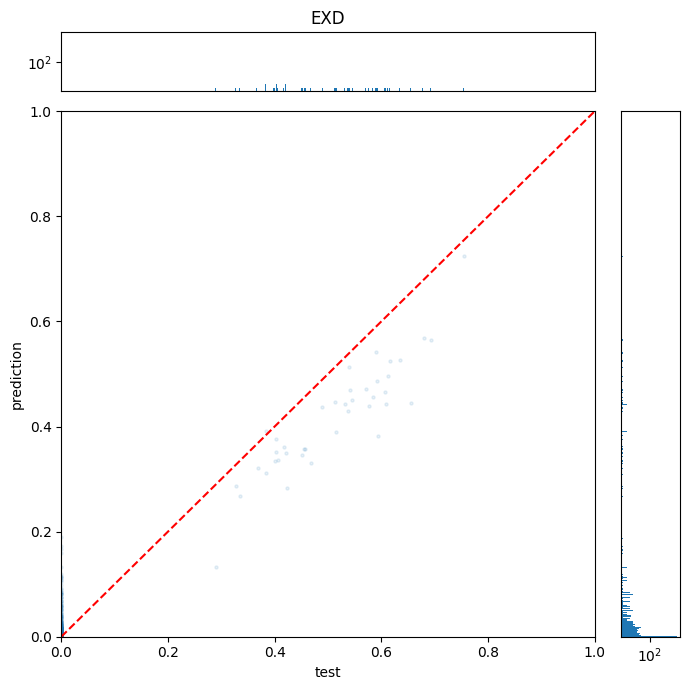

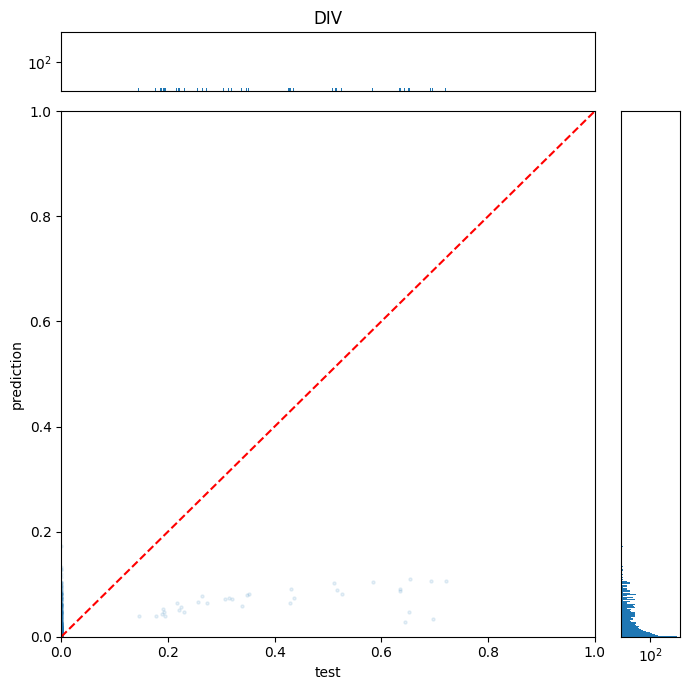

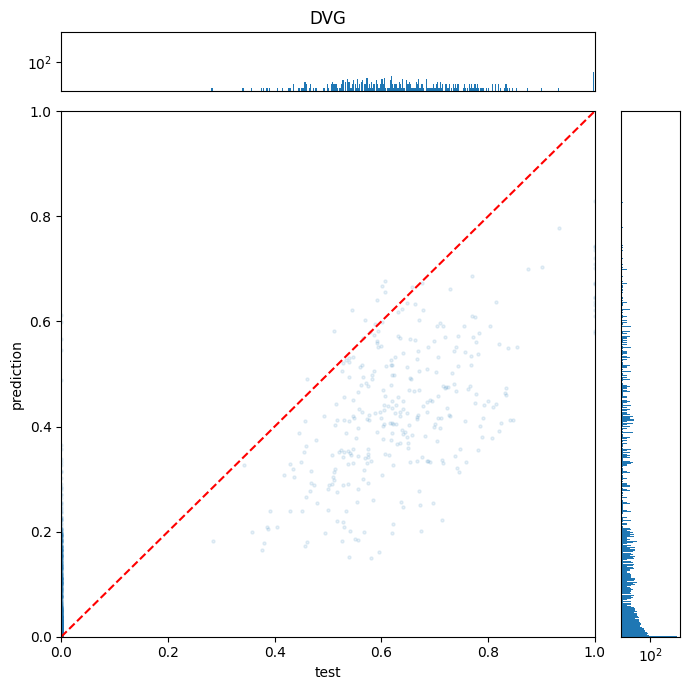

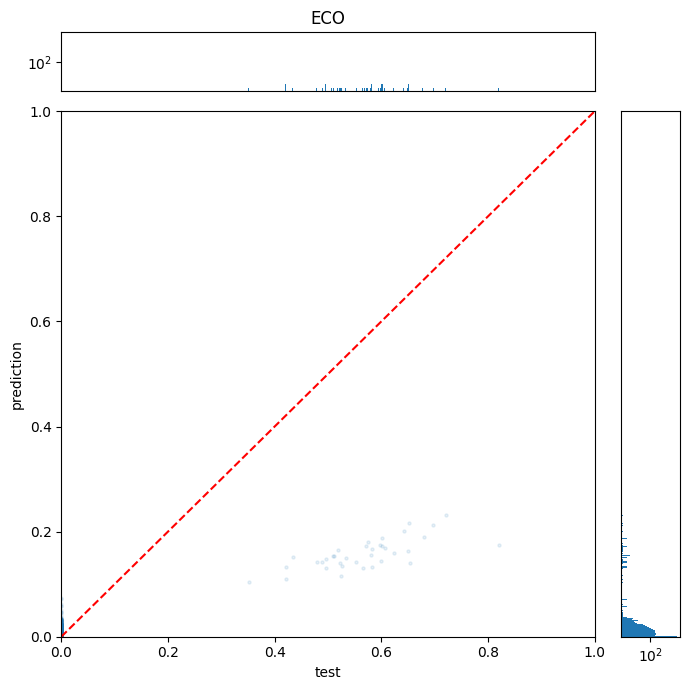

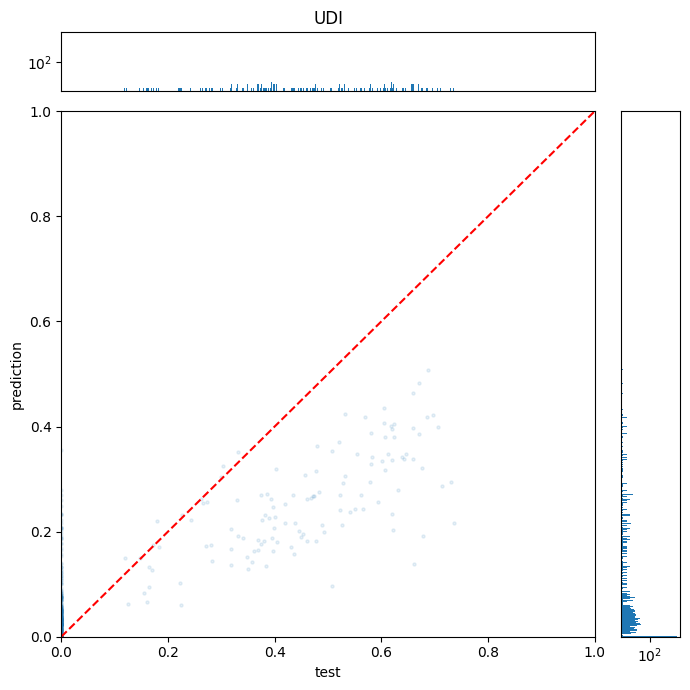

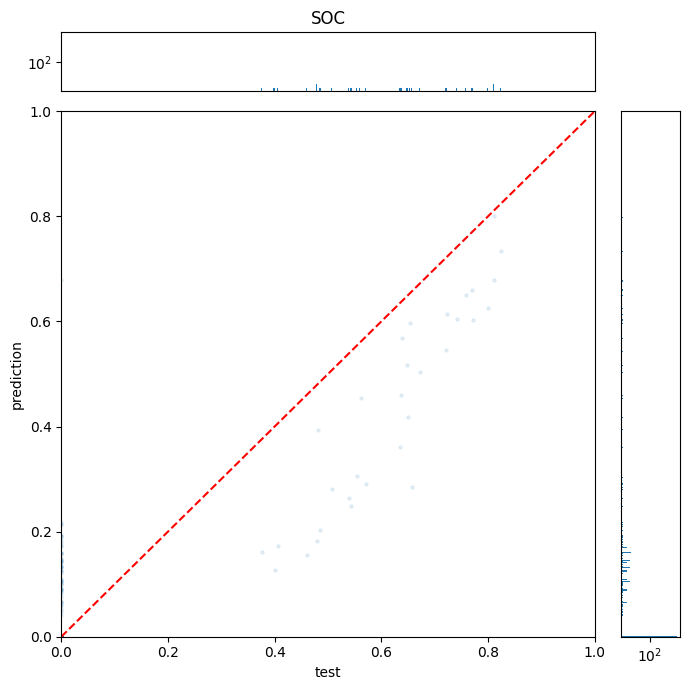

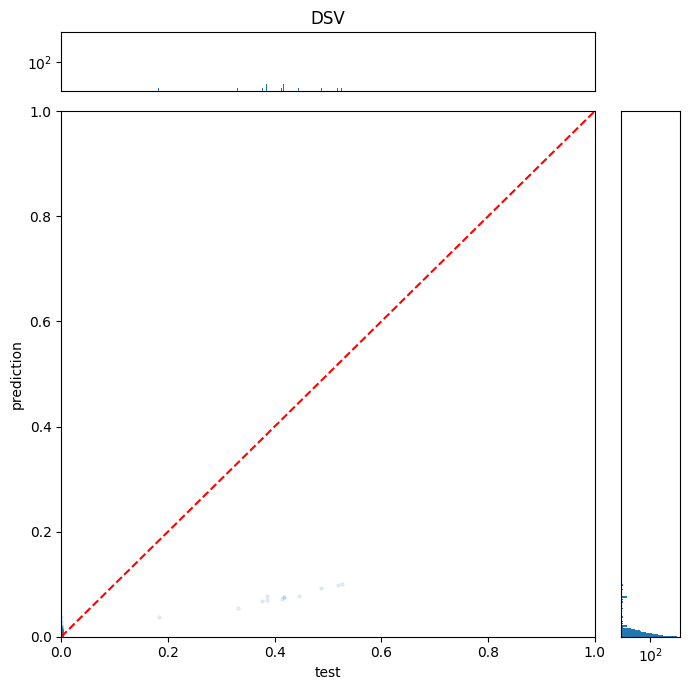

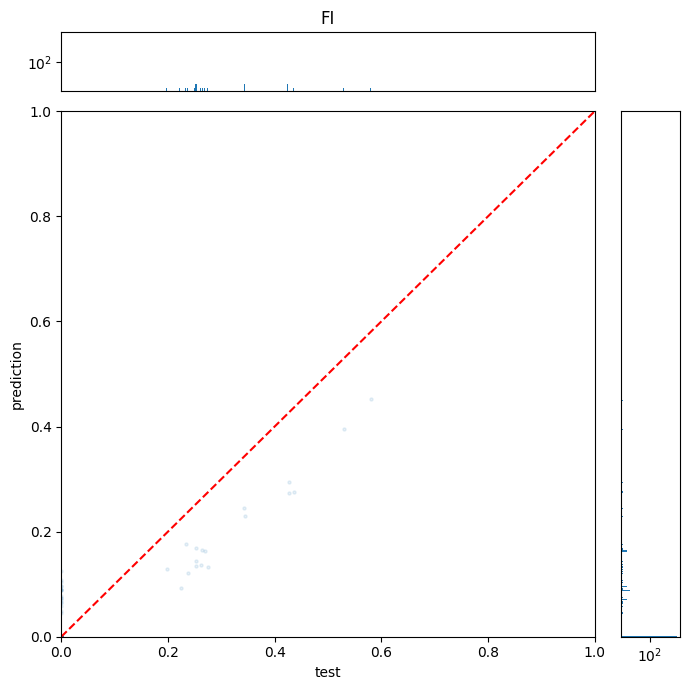

In [15]:
for i in range(test.shape[-1]):

    fig, ax = plt.subplots(
        nrows=2,
        ncols=2,
        figsize=(7,7),
        dpi=100,
        gridspec_kw={
            "height_ratios":[0.1,0.9],
            "width_ratios":[0.9,0.1]
                    }
    )

    values_test, bins_test = np.histogram(test[:,i], bins=np.linspace(test.min(), test.max(), 500))
    ax[0,0].bar(
        x=bins_test[:-1],
        height=values_test,
        width=bins_test[1]-bins_test[0]
    )
    ax[0,0].set_xticks([])
    ax[0,0].set_yscale("log")

    ax[1,0].scatter(
        x=test[:,i].reshape(-1),
        y=pred[:,i].reshape(-1),
        s=5, alpha=0.1
    )
    ax[1,0].plot(
        [0,1],
        [0,1],
        linestyle="dashed",
        color="red"
    )
    ax[1,0].set_xlabel("test")
    ax[1,0].set_ylabel("prediction")

    values_pred, bins_pred = np.histogram(pred[:,i], bins=np.linspace(pred.min(), pred.max(), 500))
    ax[1,1].barh(
        bins_pred[:-1],
        values_pred,
        height=bins_test[1]-bins_test[0]
    )

    ax[1,1].set_yticks([])
    ax[1,1].set_xscale("log")

    ax[0,1].set_axis_off()

    ax[1,0].set_xlim(0,1)
    ax[1,0].set_ylim(0,1)
    ax[0,0].set_xlim(0,1)
    ax[1,1].set_ylim(0,1)

    ax[0,0].set_title(df_2f.keys()[i])
    plt.tight_layout()
    plt.show()

In [16]:
prm.WaTer()

Last updated: 2026-08-09T13:57:44.715092+02:00

Python implementation: CPython
Python version       : 3.10.20
IPython version      : 8.37.0

Compiler    : GCC 14.3.0
OS          : Linux
Release     : 7.0.0-29-generic
Machine     : x86_64
Processor   : inconnu
CPU cores   : 8
Architecture: 64bit

